In [1]:
import os
import json
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils

In [2]:
def get_grid_metrics(path, n_cells, env_size, size_threshold, scale_method='nearest'):
    sacs = np.load(f"../results/tpc/{path}/sac.npy")[:n_cells]
    scores = np.load(f"../results/tpc/{path}/grid_scores.npy")[:n_cells]

    sizes = []
    scales = []
    for i in range(sacs.shape[0]):
        sac = sacs[i]
        res = compute_grid_metrics(sac, env_size=env_size, size_thresh_scaler=size_threshold, scale_method=scale_method)
        grid_scale = res['grid_scale_meters']
        grid_size = res['grid_size_meters']
        sizes.append(grid_size)
        scales.append(grid_scale)
    return sizes, scales, scores

In [18]:
sizes_l, scales_l, scores_l = get_grid_metrics("Apr-17-2025-12-08-03", 32, 2.2, 0.5, scale_method='average')
sizes_s, scales_s, scores_s = get_grid_metrics("Apr-07-2025-18-01-51", 32, 1.6, 0.5, scale_method='average')

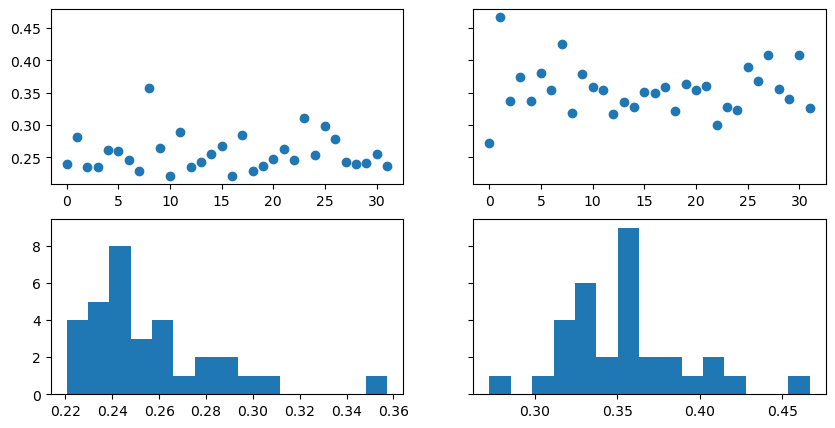

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5), sharey='row')
ax[0, 0].scatter(np.arange(len(scales_l)), scales_l)
ax[0, 1].scatter(np.arange(len(scales_s)), scales_s)
ax[1, 0].hist(scales_l, bins=15)
ax[1, 1].hist(scales_s, bins=15)
plt.show()